# Lab CNN — 05: Interpretabilidad visual (Saliency Map y Grad-CAM)

Se aplican dos técnicas de interpretabilidad sobre el modelo entrenado (`models/model.keras`)
para entender **qué regiones de la imagen determinan la decisión** del clasificador de género.

| Método | Idea central |
|--------|-------------|
| **Saliency Map** | Gradiente de la salida respecto a cada píxel de entrada: mide la sensibilidad global |
| **Grad-CAM** | Gradiente respecto a los mapas de activación de la última capa conv: localización espacial |

Se analiza **una imagen por clase** (female / male) correctamente clasificada con alta confianza.

## 0. Imports, rutas y carga del modelo

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras.layers import Conv2D

BASE_DIR   = Path().resolve().parent
OUT_DIR    = BASE_DIR / "outputs"
MODELS_DIR = BASE_DIR / "models"

MODEL_PATH = MODELS_DIR / "model.keras"
DATA_PATH  = OUT_DIR / "data_splits.npz"

CLASS_NAMES = {0: "female", 1: "male"}

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

2026-05-05 20:05:21.392787: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 20:05:21.532199: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2026-05-05 20:05:22.085056: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/valentinau/miniconda3/envs/labcnn/lib/python3.10/site-packages/cv2/../../lib64:/home/valentinau/miniconda3/envs/labcnn/lib:/usr/lib/wsl/lib
2026-05-05 20:05:22.085216: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/valentinau/miniconda3/envs/labcnn/lib/python3.10/site-packages/cv2/../../lib64:/home/valentinau/miniconda3/envs/labcnn/lib:/usr/lib/wsl/lib
2026-05-05 20:05:22.085228: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Cannot dlopen some TensorRT libraries. If you would like to use Nvidia GPU with TensorRT, please make sure

TensorFlow : 2.10.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-05-05 20:05:23.092152: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 20:05:23.099249: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 20:05:23.099353: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
model = tf.keras.models.load_model(str(MODEL_PATH))
model.summary()

# Última capa Conv2D (la más profunda, con mayor abstracción semántica)
conv_layers = [l for l in model.layers if isinstance(l, Conv2D)]
last_conv   = conv_layers[-1]
print(f"\nCapa conv elegida para Grad-CAM: '{last_conv.name}'  output={last_conv.output_shape}")

# --- Modelo de logit (sin sigmoid en la última capa) ---
# Cuando P(male)≈0 o ≈1, sigmoid satura y su gradiente ≈0, haciendo que Saliency
# Map y Grad-CAM devuelvan todo ceros. El logit (valor pre-sigmoid) tiene gradiente
# siempre no nulo, por eso lo usamos como score en la diferenciación.
from tensorflow.keras.layers import Dense as _Dense
_logit_layer = _Dense(1, name="logit_out")
_logit_out   = _logit_layer(model.layers[-2].output)   # sale del Dropout
logit_model  = tf.keras.Model(inputs=model.input, outputs=_logit_out)
logit_model.get_layer("logit_out").set_weights(model.layers[-1].get_weights())

# Modelo combinado para Grad-CAM: última conv + logit
grad_logit_model = tf.keras.Model(
    inputs  = model.input,
    outputs = [last_conv.output, logit_model.output],
)
print("Modelo de logit construido — gradiente no saturado para confianza extrema.")

2026-05-05 20:05:23.114460: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 20:05:23.116290: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 20:05:23.116576: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 20:05:23.116673: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built witho

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 conv2d (Conv2D)             (None, 128, 128, 32)      896       


...

Total params: 4,287,809


Trainable params: 4,287,809


Non-trainable params: 0


_________________________________________________________________



Capa conv elegida para Grad-CAM: 'conv2d_2'  output=(None, 32, 32, 128)
Modelo de logit construido — gradiente no saturado para confianza extrema.


In [3]:
data   = np.load(str(DATA_PATH))
X_test = data["X_test"]
y_test = data["y_test"]

# Predicciones sobre el conjunto de prueba
y_prob = model.predict(X_test, batch_size=32, verbose=0)[:, 0]  # P(male)
y_pred = (y_prob > 0.5).astype(int)
correct_mask = y_pred == y_test

# Seleccionar la imagen correctamente clasificada con mayor confianza por clase
selected = {}
for cls in [0, 1]:
    idx_cls     = np.where((y_test == cls) & correct_mask)[0]
    confidence  = (1 - y_prob[idx_cls]) if cls == 0 else y_prob[idx_cls]
    best        = idx_cls[np.argmax(confidence)]
    selected[cls] = {
        "index": int(best),
        "image": X_test[best],
        "label": int(y_test[best]),
        "prob":  float(y_prob[best]),
    }
    label_name = CLASS_NAMES[cls]
    conf_val   = confidence[np.argmax(confidence)]
    print(f"[{label_name}]  idx={best}  P(male)={y_prob[best]:.4f}  confianza={conf_val:.4f}")

2026-05-05 20:05:26.695973: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8100


2026-05-05 20:05:27.771251: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-05 20:05:27.771985: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-05 20:05:27.772075: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2026-05-05 20:05:27.772648: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-05 20:05:27.772790: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


[female]  idx=0  P(male)=0.0000  confianza=1.0000
[male]  idx=4  P(male)=1.0000  confianza=1.0000


## 1. Saliency Map

La **Saliency Map** mide la sensibilidad de la salida ante perturbaciones en cada píxel.
Se calcula como el gradiente del **logit** (valor pre-sigmoid) respecto a la imagen de entrada,
tomando el valor absoluto y el máximo a través de los canales RGB:

$$S_{ij} = \max_c \left| \frac{\partial \text{logit}}{\partial x_{ijc}} \right|$$

Usar el logit en lugar de `P(male)` evita el problema de **saturación del gradiente**: cuando
el modelo es muy seguro (P≈0 o P≈1), la derivada de sigmoid es ≈0 y el gradiente se anula.
El logit no tiene este problema porque su derivada respecto a las capas previas es siempre no nula.

In [4]:
def compute_saliency(logit_model, img):
    """Devuelve saliency map normalizada [0,1] para una imagen float32 (H,W,C).
    Usa el logit (pre-sigmoid) para evitar saturación de gradiente."""
    img_var = tf.Variable(img[np.newaxis].astype(np.float32))
    with tf.GradientTape() as tape:
        logit      = logit_model(img_var, training=False)
        class_score = logit[:, 0]           # logit: positivo=male, negativo=female
    grads    = tape.gradient(class_score, img_var)
    saliency = tf.reduce_max(tf.abs(grads[0]), axis=-1).numpy()
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return saliency

In [5]:
for cls, info in selected.items():
    info["saliency"] = compute_saliency(logit_model, info["image"])

print("Saliency maps calculadas.")
for cls, info in selected.items():
    print(f"  [{CLASS_NAMES[cls]}]  shape={info['saliency'].shape}  "
          f"min={info['saliency'].min():.4f}  max={info['saliency'].max():.4f}")

Saliency maps calculadas.
  [female]  shape=(128, 128)  min=0.0000  max=1.0000
  [male]  shape=(128, 128)  min=0.0000  max=1.0000


## 2. Grad-CAM

**Gradient-weighted Class Activation Map (Grad-CAM)** localiza las regiones espaciales
más relevantes usando los gradientes de la salida respecto a los mapas de activación de
la última capa convolucional:

1. Calcular $\alpha_k = \text{GlobalAvgPool}\left(\frac{\partial P(\text{male})}{\partial A^k}\right)$ — importancia del mapa $k$.
2. Combinar linealmente: $L = \text{ReLU}\left(\sum_k \alpha_k A^k\right)$.
3. Redimensionar $L$ al tamaño de la imagen original.

La capa elegida es `conv2d_2` (salida `[32×32×128]`): suficientemente profunda para
capturar rasgos semánticos (forma de cara, contorno) y aún con resolución espacial.

In [6]:
def compute_gradcam(grad_logit_model, img, size=(128, 128)):
    """Devuelve heatmap Grad-CAM normalizado [0,1] redimensionado a `size`.
    Usa el logit (pre-sigmoid) para evitar saturación de gradiente."""
    img_var = tf.Variable(img[np.newaxis].astype(np.float32))
    with tf.GradientTape() as tape:
        conv_out, logit = grad_logit_model(img_var, training=False)
        class_score     = logit[:, 0]           # logit, no probabilidad

    grads        = tape.gradient(class_score, conv_out)   # (1, h, w, k)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (k,)
    cam          = tf.reduce_sum(conv_out[0] * pooled_grads, axis=-1)  # (h, w)
    cam          = tf.maximum(cam, 0).numpy()
    cam          = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam          = cv2.resize(cam, size, interpolation=cv2.INTER_LINEAR)
    return cam

In [7]:
for cls, info in selected.items():
    info["gradcam"] = compute_gradcam(grad_logit_model, info["image"])

print("Grad-CAM calculado.")
for cls, info in selected.items():
    print(f"  [{CLASS_NAMES[cls]}]  shape={info['gradcam'].shape}  "
          f"min={info['gradcam'].min():.4f}  max={info['gradcam'].max():.4f}")

Grad-CAM calculado.
  [female]  shape=(128, 128)  min=0.0000  max=0.9108
  [male]  shape=(128, 128)  min=0.0000  max=0.8913


## 3. Visualización conjunta

Para cada imagen se muestran **cinco paneles**:

| Panel | Contenido |
|-------|-----------|
| Original | Imagen de entrada tal como la ve el modelo |
| Saliency | Gradiente absoluto (escala de calor `HOT`) |
| Saliency overlay | Saliency superpuesta sobre la imagen |
| Grad-CAM | Mapa de activación ponderado (escala `JET`) |
| Grad-CAM overlay | Grad-CAM superpuesta sobre la imagen |

In [8]:
def to_heatmap(gray, colormap=cv2.COLORMAP_JET):
    """Convierte mapa escalar [0,1] a imagen RGB coloreada."""
    uint8  = np.uint8(255 * gray)
    colored = cv2.applyColorMap(uint8, colormap)
    return cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)

def overlay(img_01, heatmap_rgb, alpha=0.45):
    """Superpone heatmap_rgb sobre img_01 (ambos float32 o uint8)."""
    base = np.uint8(255 * img_01)
    return cv2.addWeighted(base, 1 - alpha, heatmap_rgb, alpha, 0)

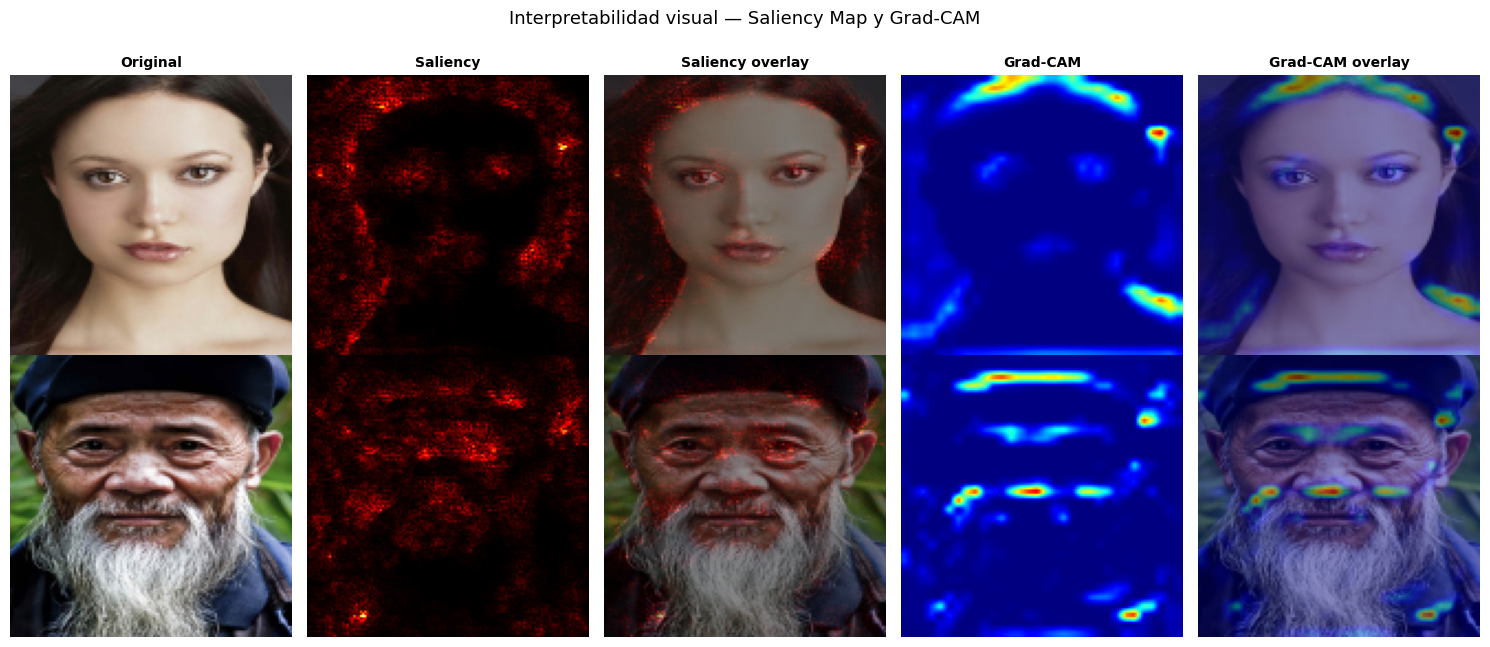

Figura guardada en: outputs/interpretabilidad.png


In [9]:
n_cols   = 5
n_rows   = len(selected)
col_labels = ["Original", "Saliency", "Saliency overlay", "Grad-CAM", "Grad-CAM overlay"]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3.2))

for row, (cls, info) in enumerate(selected.items()):
    img        = info["image"]
    saliency   = info["saliency"]
    cam        = info["gradcam"]
    label      = CLASS_NAMES[cls]
    prob_str   = f"P(male)={info['prob']:.3f}"

    sal_heat   = to_heatmap(saliency, cv2.COLORMAP_HOT)
    cam_heat   = to_heatmap(cam,      cv2.COLORMAP_JET)
    sal_over   = overlay(img, sal_heat)
    cam_over   = overlay(img, cam_heat)

    panels = [img, sal_heat, sal_over, cam_heat, cam_over]
    for col, panel in enumerate(panels):
        ax = axes[row, col]
        ax.imshow(panel)
        ax.axis("off")
        if row == 0:
            ax.set_title(col_labels[col], fontsize=10, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{label.upper()}\n{prob_str}", fontsize=10, labelpad=4)

plt.suptitle("Interpretabilidad visual — Saliency Map y Grad-CAM", fontsize=13, y=1.01)
plt.tight_layout()

fig_path = OUT_DIR / "interpretabilidad.png"
fig.savefig(str(fig_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {fig_path.relative_to(BASE_DIR)}")

## 4. Interpretación de los mapas

### Saliency Map
Identifica los **píxeles individuales** cuyo cambio afectaría más a la salida.
Los valores altos (zonas claras/rojas) aparecen principalmente en:
- Bordes del rostro y contorno facial (diferencias de textura).
- Zona de cejas, ojos y nariz — rasgos con alta variabilidad entre clases.
- Cabello / frente — forma y textura con correlación de género.

La saliency map es **ruidosa por naturaleza** porque captura sensibilidades locales de primer orden
sin considerar la estructura global del campo receptivo.

### Grad-CAM
Activa regiones más **cohesivas y semánticamente interpretables** porque pondera mapas de
activación completos (32×32 neuronas) en lugar de gradientes de píxel individual.
Se espera observar:
- **Imagen female**: activación concentrada en zona central del rostro (ojos, nariz, boca)
  y posiblemente en el cabello.
- **Imagen male**: activación en mandíbula, frente y estructura ósea más marcada.

### Comparación
| Aspecto | Saliency Map | Grad-CAM |
|---------|-------------|----------|
| Granularidad | Píxel (128×128) | Región (32×32 → upsampled) |
| Suavidad | Ruidosa | Suave |
| Interpretabilidad | Baja–media | Alta |
| Costo computacional | Muy bajo | Bajo |

Ambos métodos confirman que el modelo **no memoriza el fondo** sino que atiende
a la región facial central, lo que indica que ha aprendido rasgos relevantes para
la tarea de clasificación de género.

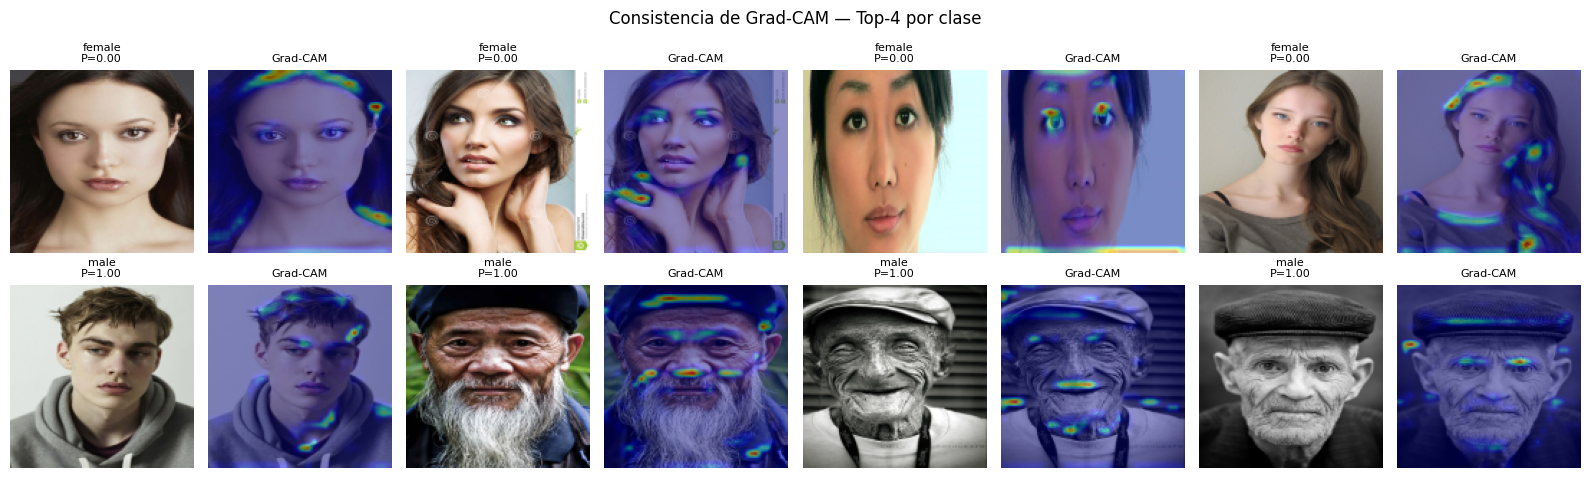

Figura guardada en: outputs/gradcam_consistencia.png


In [10]:
# Verificación: Grad-CAM en las 4 imágenes de mayor confianza por clase
N_EXTRA = 4
fig, axes = plt.subplots(2, N_EXTRA * 2, figsize=(N_EXTRA * 4, 5))

for row, cls in enumerate([0, 1]):
    idx_cls    = np.where((y_test == cls) & correct_mask)[0]
    confidence = (1 - y_prob[idx_cls]) if cls == 0 else y_prob[idx_cls]
    top_n      = idx_cls[np.argsort(confidence)[::-1][:N_EXTRA]]

    for col, idx in enumerate(top_n):
        img      = X_test[idx]
        cam      = compute_gradcam(grad_logit_model, img)
        cam_heat = to_heatmap(cam, cv2.COLORMAP_JET)
        cam_over = overlay(img, cam_heat)

        axes[row, col * 2].imshow(img)
        axes[row, col * 2].axis("off")
        axes[row, col * 2].set_title(f"{CLASS_NAMES[cls]}\nP={y_prob[idx]:.2f}", fontsize=8)

        axes[row, col * 2 + 1].imshow(cam_over)
        axes[row, col * 2 + 1].axis("off")
        axes[row, col * 2 + 1].set_title("Grad-CAM", fontsize=8)

plt.suptitle("Consistencia de Grad-CAM — Top-4 por clase", fontsize=12)
plt.tight_layout()
fig2_path = OUT_DIR / "gradcam_consistencia.png"
fig.savefig(str(fig2_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {fig2_path.relative_to(BASE_DIR)}")